# GARCH-M + Black-Litterman 포트폴리오 최적화

**파이프라인 요약**
1. S&P 500 시총 상위 30개 종목 선정
2. 주가 데이터 수집 (2016~2025)
3. GARCH-M 피팅 → Q 행렬 생성
4. Black-Litterman 사후 수익률 계산
5. 포트폴리오 최적화 (MV)
6. Walk-Forward 백테스트

## 0. 라이브러리 설치 및 임포트

In [236]:
# !pip install arch yfinance scipy scikit-learn pandas numpy matplotlib seaborn PyPortfolioOpt

In [237]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 분석 기간 설정

In [238]:
START = '2016-01-01'
END   = '2025-12-31'
RF    = 0.05  # 연 무위험수익률

print(f'분석 기간: {START} ~ {END}')
print('유니버스: Wikipedia S&P 500 동적 구성 → 시총 상위 30개 (아래 셀에서 선정)')

분석 기간: 2016-01-01 ~ 2025-12-31
유니버스: Wikipedia S&P 500 동적 구성 → 시총 상위 30개 (아래 셀에서 선정)


In [239]:
import bisect, pickle
from pathlib import Path

CACHE_DIR = Path('data')

# ── S&P 500 멤버십 히스토리 ──────────────────────────────────────────
with open(CACHE_DIR / 'sp500_membership.pkl', 'rb') as f:
    sp500_membership = pickle.load(f)

_membership_dates = sorted(sp500_membership.keys())

def get_sp500_members_at(date):
    ts = pd.Timestamp(date)
    if ts.tz is not None:
        ts = ts.tz_localize(None)
    _dates_naive = [d.tz_localize(None) if (hasattr(d, 'tz') and d.tz is not None) else d
                    for d in _membership_dates]
    idx = bisect.bisect_right(_dates_naive, ts) - 1
    if idx < 0: return set()
    return set(sp500_membership[_membership_dates[idx]])

print(f'멤버십 로드: {len(sp500_membership)}개 월')

# ── 유니버스 목록 ────────────────────────────────────────────────────
universe_df      = pd.read_csv(CACHE_DIR / 'universe.csv')
all_hist_tickers = universe_df['ticker'].tolist()
print(f'역사적 S&P 500 유니버스: {len(all_hist_tickers)}종목')

# ── 전체 가격 데이터 ─────────────────────────────────────────────────
with open(CACHE_DIR / 'prices_full.pkl', 'rb') as f:
    prices_full = pickle.load(f)
print(f'전체 가격 로드: {prices_full.shape}')

# ── 발행주식수 (시계열) → 일별 DataFrame ─────────────────────────────
with open(CACHE_DIR / 'shares_outstanding.pkl', 'rb') as f:
    shares_raw = pickle.load(f)

shares_dict = {}
for ticker, series in shares_raw.items():
    if ticker not in prices_full.columns:
        continue
    s = series.copy()
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    s = s[~s.index.duplicated(keep='last')].sort_index()
    shares_dict[ticker] = s

shares_daily = (pd.DataFrame(shares_dict)
                .reindex(prices_full.index)
                .ffill()
                .bfill())
print(f'발행주식수 로드: {len(shares_dict)}종목')

# ── 일별 시가총액 + 전체 로그수익률 ──────────────────────────────────
mcap_full        = prices_full.multiply(shares_daily)
log_returns_full = np.log(prices_full / prices_full.shift(1)).dropna(how='all')

def get_top_n_at(date, top_n=30, min_history_days=504):
    """IS 마지막 날 기준 S&P 500 시총 상위 top_n 종목 반환"""
    members   = get_sp500_members_at(date)
    available = [t for t in members if t in mcap_full.columns]
    mcap_at   = mcap_full.loc[:date].iloc[-1][available].dropna()
    has_hist  = [t for t in mcap_at.index
                 if log_returns_full[t].loc[:date].dropna().shape[0] >= min_history_days]
    return mcap_at[has_hist].nlargest(top_n).index.tolist()

print(f'\n시가총액: {mcap_full.shape}  |  수익률: {log_returns_full.shape}')


멤버십 로드: 267개 월
역사적 S&P 500 유니버스: 833종목
전체 가격 로드: (2513, 700)
발행주식수 로드: 699종목

시가총액: (2513, 700)  |  수익률: (2512, 700)


In [240]:
# END 날짜 기준 마지막 거래일 → TICKERS 동적 선정
ref_date = log_returns_full.index[log_returns_full.index <= pd.Timestamp(END)][-1]
TICKERS  = get_top_n_at(ref_date, top_n=30)

print(f'분석 유니버스 ({ref_date.date()} 기준 S&P 500 시총 상위 30개):')
print(TICKERS)

분석 유니버스 (2025-12-30 기준 S&P 500 시총 상위 30개):
['NVDA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'META', 'AVGO', 'TSLA', 'BRK-B', 'LLY', 'WMT', 'JPM', 'V', 'ORCL', 'MA', 'XOM', 'JNJ', 'PLTR', 'BAC', 'ABBV', 'NFLX', 'COST', 'AMD', 'HD', 'PG', 'GE', 'MU', 'CVX', 'CSCO', 'WFC']


# 첫 번째 IS 기간(2년) 종료 시점 기준 → 탐색용 TICKERS 선정
# (섹션 2~5 탐색용. Walk-Forward는 각 IS별로 독립적으로 재선정)
is_days  = 2 * 252
ref_date = log_returns_full.index[is_days - 1]
TICKERS  = get_top_n_at(ref_date, top_n=30)

print(f'탐색 유니버스 ({ref_date.date()} 기준 S&P 500 시총 상위 30개):')
print(TICKERS)


In [241]:
# 주가: 전체 유니버스에서 TICKERS 슬라이스
prices = prices_full[TICKERS].ffill().bfill()

print(f'최종 종목 수: {len(TICKERS)}개')
print(f'데이터 기간: {prices.index[0].date()} ~ {prices.index[-1].date()}')
print(f'총 거래일: {len(prices)}일')
prices.head()

최종 종목 수: 30개
데이터 기간: 2016-01-04 ~ 2025-12-30
총 거래일: 2513일


Ticker,NVDA,AAPL,GOOGL,MSFT,AMZN,META,AVGO,TSLA,BRK-B,LLY,WMT,JPM,V,ORCL,MA,XOM,JNJ,PLTR,BAC,ABBV,NFLX,COST,AMD,HD,PG,GE,MU,CVX,CSCO,WFC
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,0.789545,23.730949,37.660740,47.874184,31.849501,101.424080,10.853882,14.894000,130.750000,69.683701,17.039936,48.401138,70.432335,30.671431,88.991829,49.654358,75.770805,9.5,13.122293,37.397285,10.996,134.060837,2.77,102.606201,58.665794,129.863510,13.975863,57.362305,19.344133,39.700748
2016-01-05,0.802229,23.136265,37.764385,48.092594,31.689501,101.930115,10.490765,14.895333,131.250000,70.726402,17.444719,48.484814,70.962685,30.577049,89.160751,50.077465,76.087532,9.5,13.122293,37.241489,10.766,134.388519,2.75,102.105179,58.852928,129.990356,14.453756,57.852970,19.256235,39.685734
2016-01-06,0.769056,22.683496,37.655281,47.218971,31.632500,102.168243,10.168078,14.602667,131.330002,70.280708,17.619389,47.784893,70.032265,30.731483,87.796997,49.660789,75.702942,9.5,12.842752,37.247982,11.768,133.144913,2.51,101.048363,58.284019,127.918335,13.868583,55.567509,19.051147,38.927883
2016-01-07,0.738568,21.726145,36.746296,45.576588,30.396999,97.157570,9.844626,14.376667,129.479996,68.456039,18.029726,45.852512,68.655258,30.062296,86.188759,48.865913,74.820663,9.5,12.379519,37.137627,11.456,130.094666,2.28,98.167526,57.774982,122.505585,13.322422,53.598415,18.611673,37.817379
2016-01-08,0.722713,21.841028,36.245930,45.716373,30.352501,96.572151,9.779786,14.066667,128.330002,68.321457,17.616619,44.825436,67.808563,29.727695,84.542847,47.878716,74.021332,9.5,12.139919,36.124958,11.139,127.817429,2.14,96.993248,56.869194,120.306648,13.000580,53.023827,18.150225,37.187080


In [242]:
# 시가총액 비중 (ref_date 기준)
mcap_at_ref = mcap_full.loc[:ref_date].iloc[-1][TICKERS].dropna()
w_market    = (mcap_at_ref / mcap_at_ref.sum()).reindex(TICKERS).fillna(1 / len(TICKERS))

print('시가총액 비중 (상위 10개):')
print(w_market.sort_values(ascending=False).head(10).apply(lambda x: f'{x:.2%}'))

시가총액 비중 (상위 10개):
NVDA     13.21%
AAPL     11.72%
GOOGL    10.99%
MSFT     10.46%
AMZN      7.19%
META      4.85%
AVGO      4.77%
TSLA      4.37%
BRK-B     3.14%
LLY       2.80%
Name: 2025-12-30 00:00:00, dtype: object


In [243]:
# 로그 수익률 (TICKERS 슬라이스)
log_returns = log_returns_full[TICKERS]

print(f'수익률 데이터: {log_returns.shape}')
print('\n연율화 수익률 (상위 5개):')
annual_ret = log_returns.mean() * 252
print(annual_ret.sort_values(ascending=False).head().apply(lambda x: f'{x:.2%}'))

수익률 데이터: (2512, 30)

연율화 수익률 (상위 5개):
Ticker
NVDA    54.88%
AMD     43.67%
AVGO    34.82%
TSLA    34.29%
MU      30.51%
dtype: object


## 3. GARCH-M 피팅 → Q 행렬 생성

In [244]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kurtosis as sp_kurtosis

def fit_garch_m(returns_series, ticker=''):
    """
    GARCH-M 피팅 (2-step: GARCH → OLS for λ)
    + 진단 지표: AIC, BIC, Log-likelihood, Ljung-Box, ARCH-LM, 첨도
    """
    r = returns_series.dropna() * 100

    try:
        # Step 1: GARCH(1,1) 피팅
        model = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1)
        res = model.fit(disp='off', show_warning=False)

        h = res.conditional_volatility ** 2
        std_resid = (res.resid / res.conditional_volatility).dropna()

        # Step 2: OLS로 λ 추정
        X = np.column_stack([np.ones(len(r)), h.values])
        beta, _, _, _ = np.linalg.lstsq(X, r.values, rcond=None)
        mu, lambda_ = float(beta[0]), float(beta[1])

        # 1-step ahead 분산 예측
        forecast = res.forecast(horizon=1, reindex=False)
        sigma2 = float(forecast.variance.values[-1, 0])

        Q = (mu + lambda_ * sigma2) / 100 * 252
        sigma_annual = np.sqrt(sigma2) / 100 * np.sqrt(252)

        # 진단 지표
        lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
        lb_arch  = acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)

        return {
            'Q': Q,
            'mu': mu,
            'lambda_': lambda_,
            'sigma_annual': sigma_annual,
            'sigma2_daily': sigma2,
            'converged': True,
            # 진단
            'aic':       res.aic,
            'bic':       res.bic,
            'loglik':    res.loglikelihood,
            'lb_pval':   float(lb_resid['lb_pvalue'].values[0]),  # >0.05 → 잔차 자기상관 없음 (좋음)
            'arch_pval': float(lb_arch['lb_pvalue'].values[0]),   # >0.05 → ARCH 효과 제거됨 (좋음)
            'kurt':      float(sp_kurtosis(std_resid)),            # 초과 첨도 (0에 가까울수록 정규분포)
        }

    except Exception as e:
        print(f'  [{ticker}] 피팅 실패: {e}')
        return {'Q': None, 'converged': False}


print('GARCH-M 함수 정의 완료 (진단 지표 포함)')

GARCH-M 함수 정의 완료 (진단 지표 포함)


In [245]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kurtosis as sp_kurtosis

def fit_garch_m(returns_series, ticker=''):
    """
    GARCH-M 피팅 (2-step: GARCH → constrained OLS for λ)
    λ >= 0 제약: 이론상 리스크 프리미엄은 양수여야 함
    """
    r = returns_series.dropna() * 100

    try:
        # Step 1: GARCH(1,1) 피팅
        model = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1)
        res = model.fit(disp='off', show_warning=False)

        h = res.conditional_volatility ** 2
        std_resid = (res.resid / res.conditional_volatility).dropna()

        # Step 2: OLS로 λ 추정 후 λ >= 0 클리핑
        # 이론상 GARCH-M의 λ는 양수 (고변동성 = 고기대수익률)
        # 음수 λ는 단기 노이즈로 처리
        X = np.column_stack([np.ones(len(r)), h.values])
        beta, _, _, _ = np.linalg.lstsq(X, r.values, rcond=None)
        mu      = float(beta[0])
        lambda_ = max(0.0, float(beta[1]))   # 비음수 제약

        # 1-step ahead 분산 예측
        forecast = res.forecast(horizon=1, reindex=False)
        sigma2 = float(forecast.variance.values[-1, 0])

        Q = (mu + lambda_ * sigma2) / 100 * 252
        sigma_annual = np.sqrt(sigma2) / 100 * np.sqrt(252)

        # 진단 지표
        lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
        lb_arch  = acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)

        return {
            'Q': Q,
            'mu': mu,
            'lambda_': lambda_,
            'sigma_annual': sigma_annual,
            'sigma2_daily': sigma2,
            'converged': True,
            'aic':       res.aic,
            'bic':       res.bic,
            'loglik':    res.loglikelihood,
            'lb_pval':   float(lb_resid['lb_pvalue'].values[0]),
            'arch_pval': float(lb_arch['lb_pvalue'].values[0]),
            'kurt':      float(sp_kurtosis(std_resid)),
        }

    except Exception as e:
        print(f'  [{ticker}] 피팅 실패: {e}')
        return {'Q': None, 'converged': False}


print('GARCH-M 함수 정의 완료 (λ >= 0 제약 포함)')


GARCH-M 함수 정의 완료 (λ >= 0 제약 포함)


=== GARCH-M 진단 지표 ===
  LB p-val  > 0.05 → 잔차 자기상관 없음 (좋음)
  ARCH p-val > 0.05 → ARCH 효과 제거됨  (좋음)
  초과첨도 ≈ 0     → 정규분포에 가까움  (참고용)

              AIC         BIC     LogLik  LB p-val\n(잔차)  ARCH p-val\n(잔차²)      초과첨도
NVDA   12589.5666  12612.8820 -6290.7833          0.4760             0.9137    7.7862
AAPL    9612.4885   9635.8039 -4802.2443          0.2640             0.8682    3.1510
GOOGL   9826.5086   9849.8239 -4909.2543          0.1207             0.9873    5.0937
MSFT    9158.4845   9181.7998 -4575.2422          0.0292             0.9480    3.3256
AMZN   10329.0568  10352.3722 -5160.5284          0.8066             0.9407    5.5288
META   11299.4309  11322.7462 -5645.7154          0.6946             0.9966   24.3456
AVGO   11116.8965  11140.2119 -5554.4483          0.4533             0.6294    5.9128
TSLA   13429.5312  13452.8465 -6710.7656          0.2566             0.3288    3.5982
BRK-B   7444.1321   7467.4474 -3718.0660          0.4109             0.9013    3.3644
LLY   

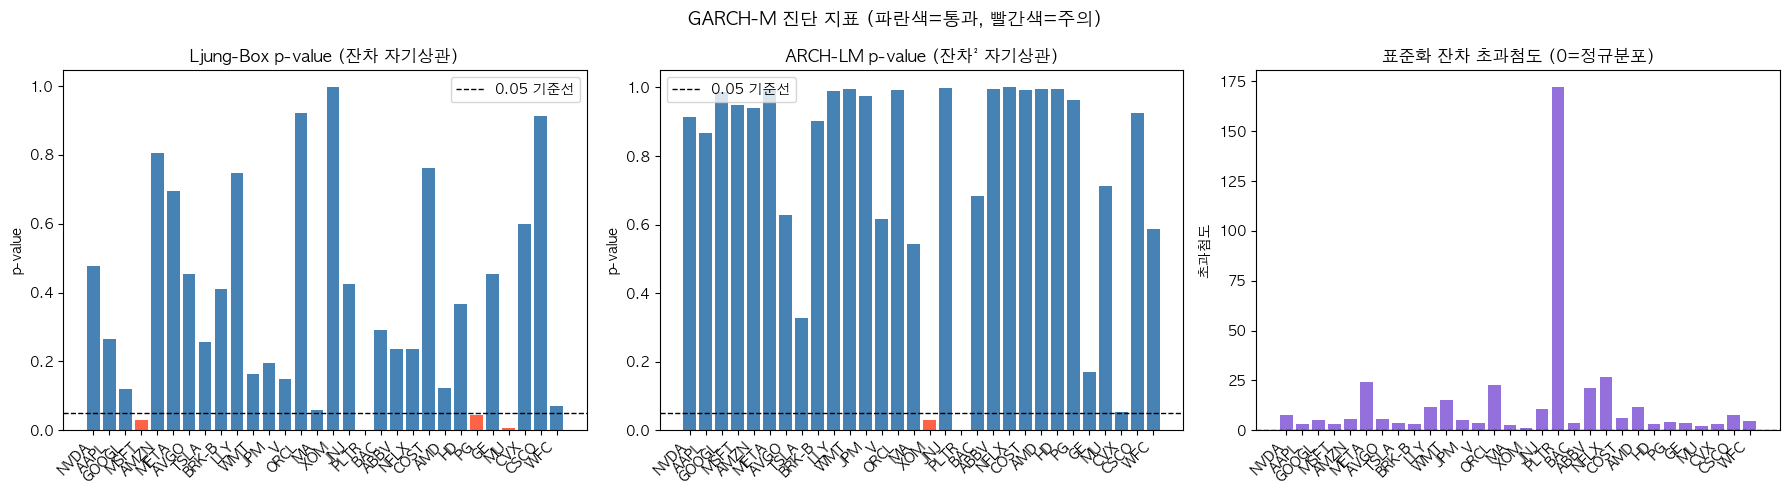

In [246]:
# GARCH-M 진단 지표 요약 테이블
diag_cols = ['aic', 'bic', 'loglik', 'lb_pval', 'arch_pval', 'kurt']
diag_df = pd.DataFrame(
    {t: {k: r[k] for k in diag_cols} for t, r in garch_results.items() if r['converged']}
).T.rename(columns={
    'aic':       'AIC',
    'bic':       'BIC',
    'loglik':    'LogLik',
    'lb_pval':   'LB p-val\n(잔차)',
    'arch_pval': 'ARCH p-val\n(잔차²)',
    'kurt':      '초과첨도'
})

# 판정 기준 안내
print('=== GARCH-M 진단 지표 ===')
print('  LB p-val  > 0.05 → 잔차 자기상관 없음 (좋음)')
print('  ARCH p-val > 0.05 → ARCH 효과 제거됨  (좋음)')
print('  초과첨도 ≈ 0     → 정규분포에 가까움  (참고용)\n')
print(diag_df.round(4).to_string())

# 판정 요약
lb_ok   = (diag_df['LB p-val\n(잔차)']   > 0.05).sum()
arch_ok = (diag_df['ARCH p-val\n(잔차²)'] > 0.05).sum()
n = len(diag_df)
print(f'\nLB   통과: {lb_ok}/{n}  ({lb_ok/n:.0%})')
print(f'ARCH 통과: {arch_ok}/{n}  ({arch_ok/n:.0%})')

# ── 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) LB p-value (잔차 자기상관)
colors_lb = ['steelblue' if v > 0.05 else 'tomato'
             for v in diag_df['LB p-val\n(잔차)']]
axes[0].bar(diag_df.index, diag_df['LB p-val\n(잔차)'], color=colors_lb)
axes[0].axhline(0.05, color='black', linestyle='--', linewidth=1, label='0.05 기준선')
axes[0].set_title('Ljung-Box p-value (잔차 자기상관)')
axes[0].set_ylabel('p-value')
axes[0].set_xticklabels(diag_df.index, rotation=45, ha='right')
axes[0].legend()

# 2) ARCH-LM p-value (잔차² 자기상관)
colors_arch = ['steelblue' if v > 0.05 else 'tomato'
               for v in diag_df['ARCH p-val\n(잔차²)']]
axes[1].bar(diag_df.index, diag_df['ARCH p-val\n(잔차²)'], color=colors_arch)
axes[1].axhline(0.05, color='black', linestyle='--', linewidth=1, label='0.05 기준선')
axes[1].set_title('ARCH-LM p-value (잔차² 자기상관)')
axes[1].set_ylabel('p-value')
axes[1].set_xticklabels(diag_df.index, rotation=45, ha='right')
axes[1].legend()

# 3) 초과 첨도
axes[2].bar(diag_df.index, diag_df['초과첨도'], color='mediumpurple')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('표준화 잔차 초과첨도 (0=정규분포)')
axes[2].set_ylabel('초과첨도')
axes[2].set_xticklabels(diag_df.index, rotation=45, ha='right')

plt.suptitle('GARCH-M 진단 지표 (파란색=통과, 빨간색=주의)', fontsize=13)
plt.tight_layout()
plt.show()

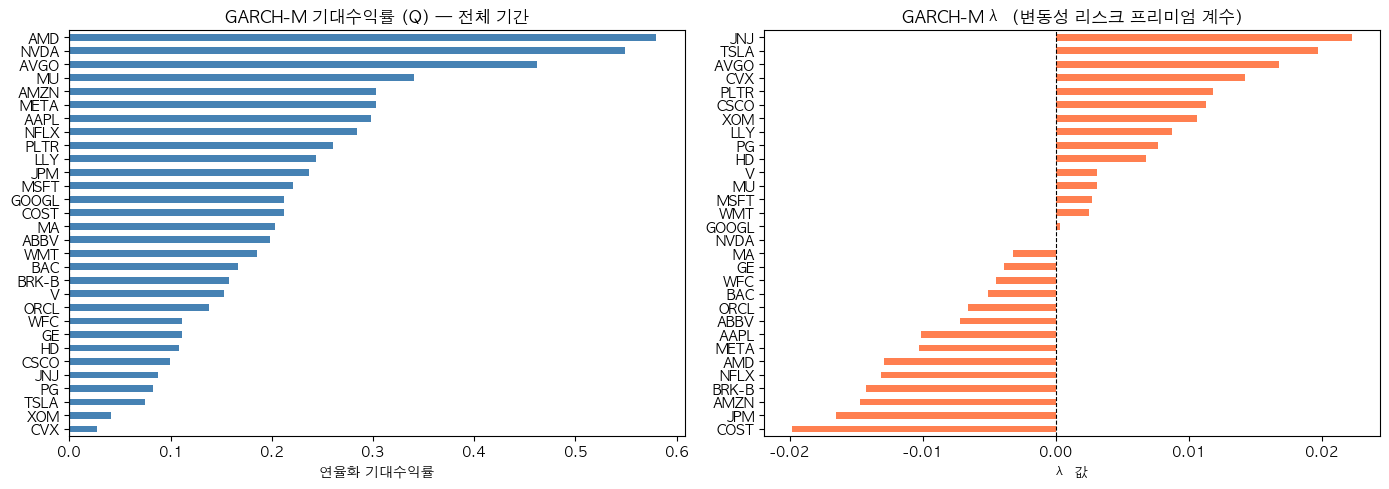

In [247]:
# GARCH-M 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q 분포
Q_series.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('GARCH-M 기대수익률 (Q) — 전체 기간')
axes[0].set_xlabel('연율화 기대수익률')

# λ 분포
lambda_series = pd.Series({
    t: r['lambda_'] for t, r in garch_results.items() if r['converged']
})
lambda_series.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('GARCH-M λ (변동성 리스크 프리미엄 계수)')
axes[1].set_xlabel('λ 값')

plt.tight_layout()
plt.show()

## 4. Black-Litterman 사후 수익률 계산

In [248]:
def compute_bl_posterior(
    returns_IS,
    w_market,
    Q_vector,
    tau=0.05,
    lambda_bl=2.5
):
    """
    Black-Litterman 사후 수익률 계산
    
    Parameters
    ----------
    returns_IS   : pd.DataFrame, IS 구간 수익률
    w_market     : pd.Series, 시가총액 비중
    Q_vector     : pd.Series, GARCH-M으로 생성한 기대수익률 견해
    tau          : float, 불확실성 스케일 (0.01~0.1)
    lambda_bl    : float, 위험회피계수
    
    Returns
    -------
    mu_bl  : np.ndarray, BL 사후 기대수익률
    cov_bl : np.ndarray, BL 사후 공분산 행렬
    """
    tickers = returns_IS.columns.tolist()
    n = len(tickers)

    # 공분산 행렬 (Ledoit-Wolf)
    cov = LedoitWolf().fit(returns_IS).covariance_ * 252

    # 시장 균형 수익률 Π
    w = w_market.reindex(tickers).fillna(1/n).values
    PI = lambda_bl * cov @ w

    # Q, P, Ω 설정 (절대적 견해)
    Q = Q_vector.reindex(tickers).values
    P = np.eye(n)          # 절대적 견해: 각 자산에 1:1 대응

    # Ω: 예측 변동성 기반 견해 불확실성
    sigma_dict = {
        t: r['sigma_annual'] for t, r in garch_results.items() if r['converged']
    }
    sigma_series = pd.Series(sigma_dict).reindex(tickers).fillna(
        pd.Series(sigma_dict).mean()
    )
    Omega = np.diag(sigma_series.values ** 2)

    # BL 공식
    tau_cov = tau * cov
    tau_cov_inv = np.linalg.inv(tau_cov)
    P_Omega_inv = P.T @ np.linalg.inv(Omega) @ P

    M_inv = np.linalg.inv(tau_cov_inv + P_Omega_inv)
    mu_bl = M_inv @ (tau_cov_inv @ PI + P.T @ np.linalg.inv(Omega) @ Q)

    cov_bl = cov + M_inv

    return mu_bl, cov_bl, PI


print('BL 함수 정의 완료')

BL 함수 정의 완료


In [249]:
def compute_bl_posterior(
    returns_IS,
    w_market,
    Q_vector,
    garch_fits=None,   # dict {ticker: fit_result} → CCC 공분산 사용
    tau=None,
    lambda_bl=2.5
):
    """
    Black-Litterman 사후 수익률 계산

    공분산 행렬 구성 방식:
      garch_fits 제공 시 → CCC-GARCH
        R  = LedoitWolf 상관관계 (IS 전체, robust)
        D  = diag(GARCH σ_i)     (IS 끝 시점 예측, Q와 시점 일치)
        Σ  = D @ R @ D
      미제공 시 → LedoitWolf fallback

    τ = 1/T (He-Litterman 표준), Ω = diag(P @ τΣ @ P')
    """
    tickers = returns_IS.columns.tolist()
    n = len(tickers)
    T = len(returns_IS)

    if tau is None:
        tau = 1 / T

    # ── 공분산 행렬 ──────────────────────────────────────────────────
    lw_cov = LedoitWolf().fit(returns_IS).covariance_ * 252
    lw_std = np.sqrt(np.diag(lw_cov))
    # 순수 상관관계 행렬 (변동성 정보 분리)
    R = lw_cov / np.outer(lw_std, lw_std)

    if garch_fits is not None:
        # CCC: GARCH 마지막 시점 σ로 D 교체 → Q와 시점 일치
        sigma = np.array([
            garch_fits[t]['sigma_annual'] if (t in garch_fits and garch_fits[t].get('converged'))
            else lw_std[i]
            for i, t in enumerate(tickers)
        ])
    else:
        sigma = lw_std   # fallback: LedoitWolf 그대로

    D   = np.diag(sigma)
    cov = D @ R @ D      # Σ = D @ R @ D
    # ─────────────────────────────────────────────────────────────────

    # 시장 균형 수익률 Π
    w  = w_market.reindex(tickers).fillna(1/n).values
    PI = lambda_bl * cov @ w

    # Q, P (절대적 견해)
    Q = Q_vector.reindex(tickers).values
    P = np.eye(n)

    # Ω: He-Litterman 비례 방식
    Omega = np.diag(np.diag(P @ (tau * cov) @ P.T))

    # BL 공식
    tau_cov     = tau * cov
    tau_cov_inv = np.linalg.inv(tau_cov)
    P_Omega_inv = P.T @ np.linalg.inv(Omega) @ P

    M_inv  = np.linalg.inv(tau_cov_inv + P_Omega_inv)
    mu_bl  = M_inv @ (tau_cov_inv @ PI + P.T @ np.linalg.inv(Omega) @ Q)
    cov_bl = cov + M_inv

    return mu_bl, cov_bl, PI


print('BL 함수 정의 완료 (CCC-GARCH 공분산, τ=1/T, Ω=He-Litterman)')


BL 함수 정의 완료 (CCC-GARCH 공분산, τ=1/T, Ω=He-Litterman)


In [250]:
# 전체 기간 BL 테스트 (CCC-GARCH 공분산 사용)
mu_bl, cov_bl, PI = compute_bl_posterior(
    log_returns,
    w_market,
    Q_series,
    garch_fits=garch_results   # GARCH σ로 공분산 스케일링
)

# 결과 비교
comparison = pd.DataFrame({
    'Π (시장균형)': PI,
    'Q (GARCH-M 견해)': Q_series.reindex(TICKERS).values,
    'μ_BL (사후)': mu_bl
}, index=TICKERS)

print('BL 수익률 비교 (연율화):')
print(comparison.applymap(lambda x: f'{x:.4f}'))


BL 수익률 비교 (연율화):
      Π (시장균형) Q (GARCH-M 견해) μ_BL (사후)
NVDA    0.1457         0.5487    0.4339
AAPL    0.0629         0.2984    0.2163
GOOGL   0.0999         0.2123    0.2709
MSFT    0.0653         0.2211    0.2020
AMZN    0.0701         0.3033    0.2366
META    0.0841         0.3030    0.2680
AVGO    0.1631         0.4620    0.4279
TSLA    0.1269         0.0749    0.2421
BRK-B   0.0396         0.1574    0.1298
LLY     0.0375         0.2441    0.1780
WMT     0.0298         0.1850    0.1376
JPM     0.0533         0.2365    0.1649
V       0.0566         0.1531    0.1753
ORCL    0.1132         0.1380    0.2524
MA      0.0493         0.2029    0.1601
XOM     0.0321         0.0411    0.0625
JNJ     0.0228         0.0871    0.0892
PLTR    0.0670         0.2605    0.2121
BAC     0.0547         0.1671    0.1591
ABBV    0.0326         0.1986    0.1444
NFLX    0.0936         0.2843    0.2939
COST    0.0464         0.2122    0.1798
AMD     0.1400         0.5791    0.4595
HD      0.0565         

## 5. 포트폴리오 최적화 (Mean-Variance)

In [251]:
def optimize_mv_bl(mu_bl, cov_bl, rf=0.05, allow_short=False):
    """
    BL 사후 수익률 기반 최대 샤프비율 포트폴리오
    """
    n = len(mu_bl)

    def neg_sharpe(w):
        ret  = w @ mu_bl
        vol  = np.sqrt(w @ cov_bl @ w)
        return -(ret - rf) / vol

    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n if not allow_short else [(-0.1, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(
        neg_sharpe, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    return result.x if result.success else w0


# 전체 기간 최적화
w_opt = optimize_mv_bl(mu_bl, cov_bl, rf=RF)
weights_bl = pd.Series(w_opt, index=TICKERS).sort_values(ascending=False)

print('BL 최적 가중치 (상위 15개):')
print(weights_bl.head(15).apply(lambda x: f'{x:.4f}'))
print(f'\n비중 합계: {weights_bl.sum():.6f}')
print(f'0 이상 종목 수: {(weights_bl > 0.001).sum()}개')

BL 최적 가중치 (상위 15개):
AAPL     0.2266
NVDA     0.1558
AMZN     0.1477
LLY      0.1248
META     0.0770
WMT      0.0668
AMD      0.0658
ABBV     0.0583
COST     0.0558
AVGO     0.0093
NFLX     0.0082
PLTR     0.0039
BAC      0.0000
GOOGL    0.0000
MSFT     0.0000
dtype: object

비중 합계: 1.000000
0 이상 종목 수: 12개


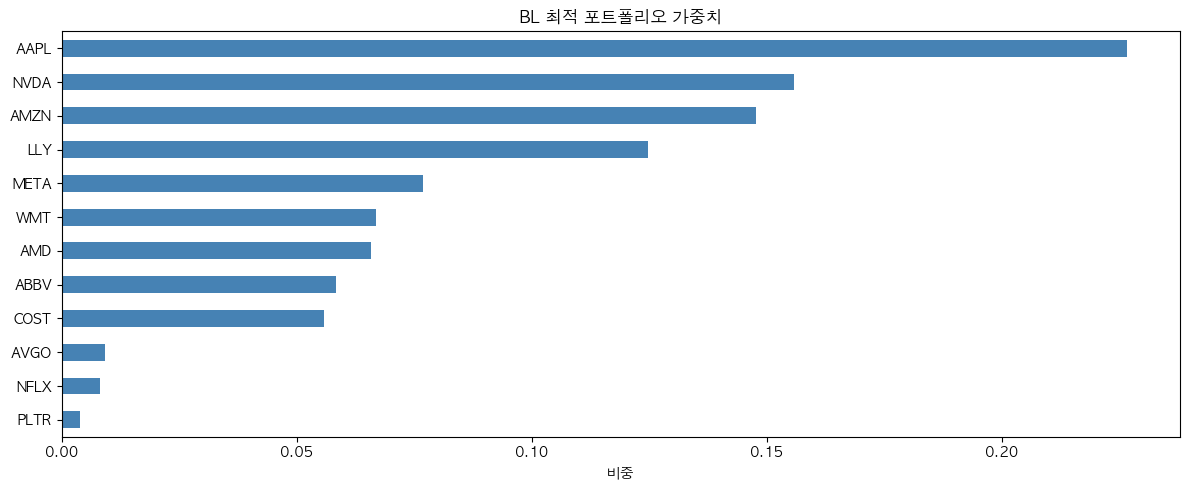

In [252]:
# 가중치 시각화
fig, ax = plt.subplots(figsize=(12, 5))
weights_bl[weights_bl > 0.001].sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_title('BL 최적 포트폴리오 가중치')
ax.set_xlabel('비중')
plt.tight_layout()
plt.show()

## 6. Walk-Forward 백테스트 (동적 유니버스)

In [253]:
def walk_forward_backtest(is_years=2, oos_months=3, rf=0.05, top_n=30):
    """Walk-Forward 백테스트 — IS 기준 S&P 500 시총 상위 top_n 동적 선정"""
    is_days  = is_years * 252
    oos_days = oos_months * 21

    all_dates         = log_returns_full.index
    portfolio_returns = []
    benchmark_returns = []
    window_info       = []
    start_idx         = is_days

    while start_idx + oos_days <= len(all_dates):
        is_end_date    = all_dates[start_idx - 1]
        oos_start      = all_dates[start_idx]
        oos_end        = all_dates[min(start_idx + oos_days - 1, len(all_dates) - 1)]

        # 동적 top-N 선정
        window_tickers = get_top_n_at(is_end_date, top_n=top_n, min_history_days=is_days)
        if len(window_tickers) < top_n // 2:
            print(f'  SKIP {oos_start.date()}: 유효 종목 부족 ({len(window_tickers)}개)')
            start_idx += oos_days
            continue

        is_data       = (log_returns_full[window_tickers]
                         .iloc[start_idx - is_days : start_idx]
                         .dropna(axis=1, how='any'))
        clean_tickers = is_data.columns.tolist()
        oos_data      = log_returns_full[clean_tickers].iloc[start_idx : start_idx + oos_days]

        # IS 기준 시가총액 비중
        mcap_at = mcap_full.loc[:is_end_date].iloc[-1][clean_tickers].dropna()
        w_mkt   = (mcap_at / mcap_at.sum()).reindex(clean_tickers).fillna(1 / len(clean_tickers))

        # GARCH-M 피팅
        q_dict, sigma_dict = {}, {}
        for ticker in clean_tickers:
            res = fit_garch_m(is_data[ticker], ticker=ticker)
            if res['converged']:
                q_dict[ticker]     = res['Q']
                sigma_dict[ticker] = res['sigma_annual']

        if len(q_dict) < len(clean_tickers) * 0.8:
            start_idx += oos_days
            continue

        Q_vec = pd.Series(q_dict)

        # BL + 최적화
        try:
            global garch_results
            garch_results_bak = garch_results
            garch_results = {t: {'sigma_annual': sigma_dict.get(t, 0.2), 'converged': True}
                             for t in clean_tickers}
            mu_bl, cov_bl, _ = compute_bl_posterior(is_data, w_mkt, Q_vec)
            w_opt             = optimize_mv_bl(mu_bl, cov_bl, rf=rf)
            garch_results     = garch_results_bak
        except Exception:
            garch_results = garch_results_bak
            start_idx += oos_days
            continue

        port_ret  = oos_data.values @ w_opt
        bench_ret = oos_data.mean(axis=1).values

        portfolio_returns.extend(port_ret)
        benchmark_returns.extend(bench_ret)
        window_info.append({'oos_start': oos_start, 'oos_end': oos_end,
                            'tickers': clean_tickers, 'n_converged': len(q_dict)})
        start_idx += oos_days
        print(f'  완료: {oos_start.date()} ~ {oos_end.date()} '
              f'| {clean_tickers[0]}…{clean_tickers[-1]} '
              f'| 수렴 {len(q_dict)}/{len(clean_tickers)}')

    idx_slice    = log_returns_full.index[is_days : is_days + len(portfolio_returns)]
    port_series  = pd.Series(portfolio_returns, index=idx_slice)
    bench_series = pd.Series(benchmark_returns, index=idx_slice)
    return port_series, bench_series, window_info


print('Walk-Forward 함수 정의 완료 (동적 유니버스 버전)')

Walk-Forward 함수 정의 완료 (동적 유니버스 버전)


In [254]:
def walk_forward_backtest(is_years=2, oos_months=3, rf=0.05, top_n=30, cost_bps=10):
    """
    Walk-Forward 백테스트 — IS 기준 S&P 500 시총 상위 top_n 동적 선정
    공분산: CCC-GARCH (GARCH σ × LedoitWolf 상관관계)
    거래비용: 편도 cost_bps (기본 10bps)
    """
    is_days   = is_years * 252
    oos_days  = oos_months * 21
    cost_rate = cost_bps / 10_000

    all_dates         = log_returns_full.index
    portfolio_returns = []
    benchmark_returns = []
    window_info       = []
    start_idx         = is_days

    w_prev       = None
    prev_tickers = None

    while start_idx + oos_days <= len(all_dates):
        is_end_date = all_dates[start_idx - 1]
        oos_start   = all_dates[start_idx]
        oos_end     = all_dates[min(start_idx + oos_days - 1, len(all_dates) - 1)]

        # 동적 top-N 선정
        window_tickers = get_top_n_at(is_end_date, top_n=top_n, min_history_days=is_days)
        if len(window_tickers) < top_n // 2:
            print(f'  SKIP {oos_start.date()}: 유효 종목 부족 ({len(window_tickers)}개)')
            start_idx += oos_days
            continue

        is_data = (log_returns_full[window_tickers]
                   .iloc[start_idx - is_days : start_idx]
                   .dropna(axis=1, how='any'))
        clean_tickers = is_data.columns.tolist()
        oos_data = log_returns_full[clean_tickers].iloc[start_idx : start_idx + oos_days]

        # IS 기준 시가총액 비중
        mcap_at = mcap_full.loc[:is_end_date].iloc[-1][clean_tickers].dropna()
        w_mkt   = (mcap_at / mcap_at.sum()).reindex(clean_tickers).fillna(1 / len(clean_tickers))

        # GARCH-M 피팅 (결과 전체 보존 → CCC 공분산에 활용)
        fit_dict = {}
        for ticker in clean_tickers:
            res = fit_garch_m(is_data[ticker], ticker=ticker)
            if res['converged']:
                fit_dict[ticker] = res

        q_dict = {t: r['Q'] for t, r in fit_dict.items()}

        if len(q_dict) < len(clean_tickers) * 0.8:
            start_idx += oos_days
            continue

        Q_vec = pd.Series(q_dict)

        # BL + 최적화 (CCC 공분산 전달)
        try:
            mu_bl, cov_bl, _ = compute_bl_posterior(
                is_data, w_mkt, Q_vec, garch_fits=fit_dict
            )
            w_opt = optimize_mv_bl(mu_bl, cov_bl, rf=rf)
        except Exception:
            start_idx += oos_days
            continue

        # ── 거래비용 ──────────────────────────────────────────────────
        new_w = pd.Series(w_opt, index=clean_tickers)
        if w_prev is not None:
            prev_w   = pd.Series(w_prev, index=prev_tickers)
            all_t    = new_w.index.union(prev_w.index)
            turnover = (new_w.reindex(all_t).fillna(0) -
                        prev_w.reindex(all_t).fillna(0)).abs().sum() / 2
        else:
            turnover = new_w.sum()
        transaction_cost = turnover * cost_rate
        # ──────────────────────────────────────────────────────────────

        port_ret    = oos_data.values @ w_opt
        port_ret[0] -= transaction_cost

        bench_ret = oos_data.mean(axis=1).values

        portfolio_returns.extend(port_ret)
        benchmark_returns.extend(bench_ret)
        window_info.append({
            'oos_start': oos_start, 'oos_end': oos_end,
            'tickers': clean_tickers, 'n_converged': len(q_dict),
            'turnover': turnover, 'cost': transaction_cost
        })

        w_prev       = w_opt
        prev_tickers = clean_tickers
        start_idx   += oos_days

        print(f'  완료: {oos_start.date()} ~ {oos_end.date()} '
              f'| 수렴 {len(q_dict)}/{len(clean_tickers)} '
              f'| turnover {turnover:.1%} | cost {transaction_cost*10000:.1f}bps')

    idx_slice    = log_returns_full.index[is_days : is_days + len(portfolio_returns)]
    port_series  = pd.Series(portfolio_returns, index=idx_slice)
    bench_series = pd.Series(benchmark_returns, index=idx_slice)
    return port_series, bench_series, window_info


print('Walk-Forward 함수 정의 완료 (CCC-GARCH + 거래비용 반영)')


Walk-Forward 함수 정의 완료 (CCC-GARCH + 거래비용 반영)


In [255]:
def compute_metrics(returns_series, rf_daily=0.05/252):
    """연율화 성과 지표 계산"""
    ann_ret = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe  = (ann_ret - 0.05) / ann_vol

    cum     = (1 + returns_series).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    mdd     = drawdown.min()

    return {
        '연수익률': f'{ann_ret:.2%}',
        '연변동성': f'{ann_vol:.2%}',
        '샤프비율': f'{sharpe:.3f}',
        'MDD':      f'{mdd:.2%}'
    }


metrics_bl    = compute_metrics(port_ret)
metrics_bench = compute_metrics(bench_ret)

metrics_df = pd.DataFrame({
    'BL + GARCH-M': metrics_bl,
    '동일비중 벤치마크': metrics_bench
})

print('=== 성과 비교 ===')
print(metrics_df.to_string())

=== 성과 비교 ===
     BL + GARCH-M 동일비중 벤치마크
연수익률       16.55%     8.91%
연변동성       26.43%    19.32%
샤프비율        0.437     0.202
MDD       -34.18%   -37.40%


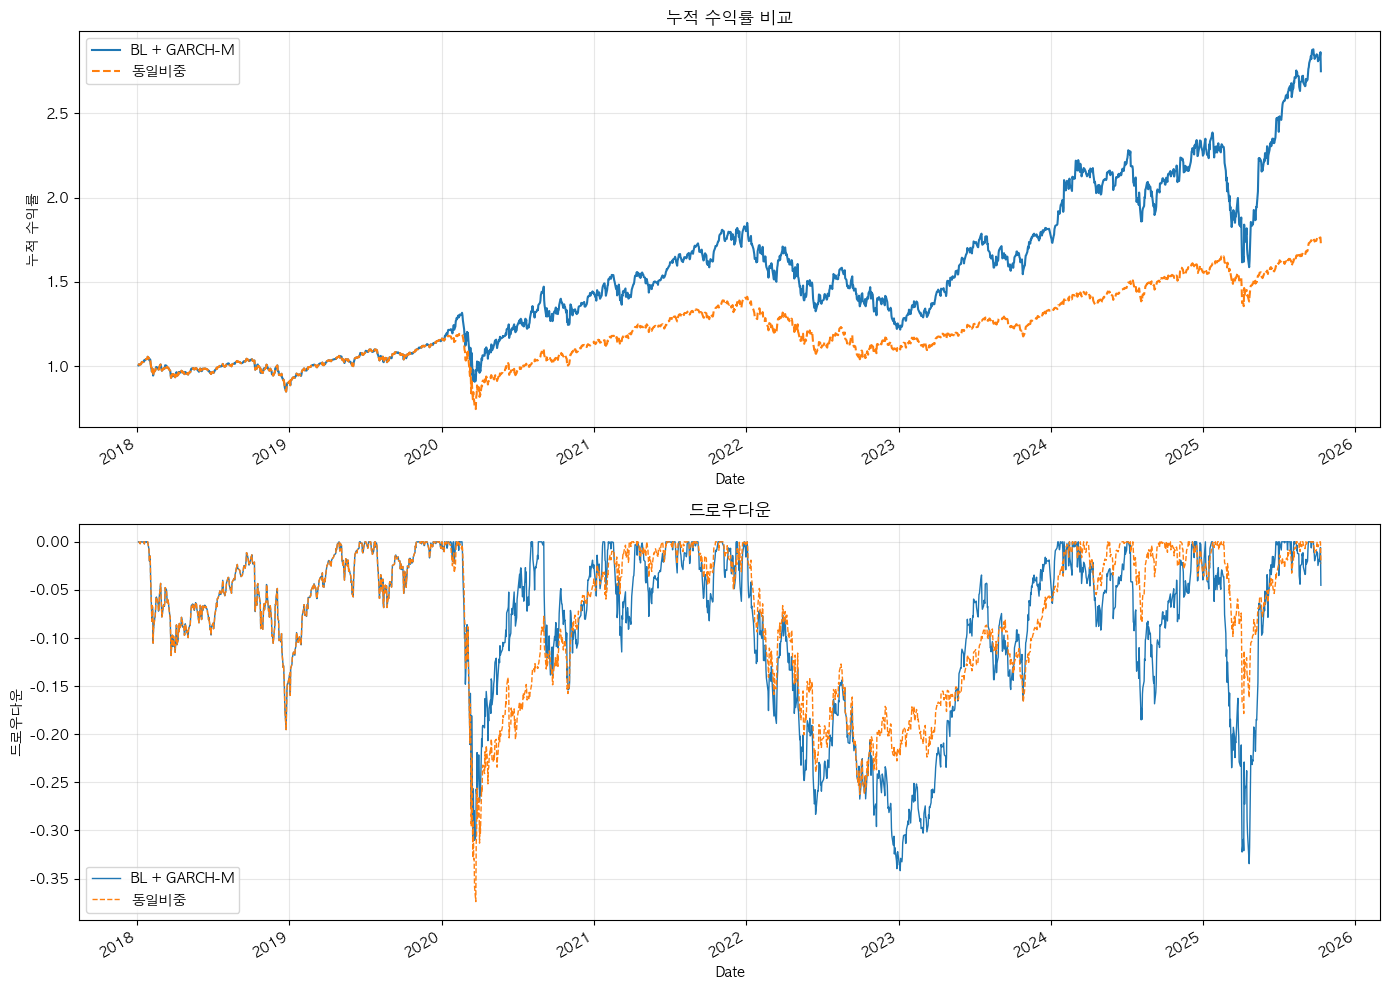

In [256]:
# 누적 수익률 시각화
cum_bl    = (1 + port_ret).cumprod()
cum_bench = (1 + bench_ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 누적 수익률
cum_bl.plot(ax=axes[0], label='BL + GARCH-M', linewidth=1.5)
cum_bench.plot(ax=axes[0], label='동일비중', linewidth=1.5, linestyle='--')
axes[0].set_title('누적 수익률 비교')
axes[0].set_ylabel('누적 수익률')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 드로우다운
def calc_drawdown(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

calc_drawdown(port_ret).plot(ax=axes[1], label='BL + GARCH-M', linewidth=1)
calc_drawdown(bench_ret).plot(ax=axes[1], label='동일비중', linewidth=1, linestyle='--')
axes[1].set_title('드로우다운')
axes[1].set_ylabel('드로우다운')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

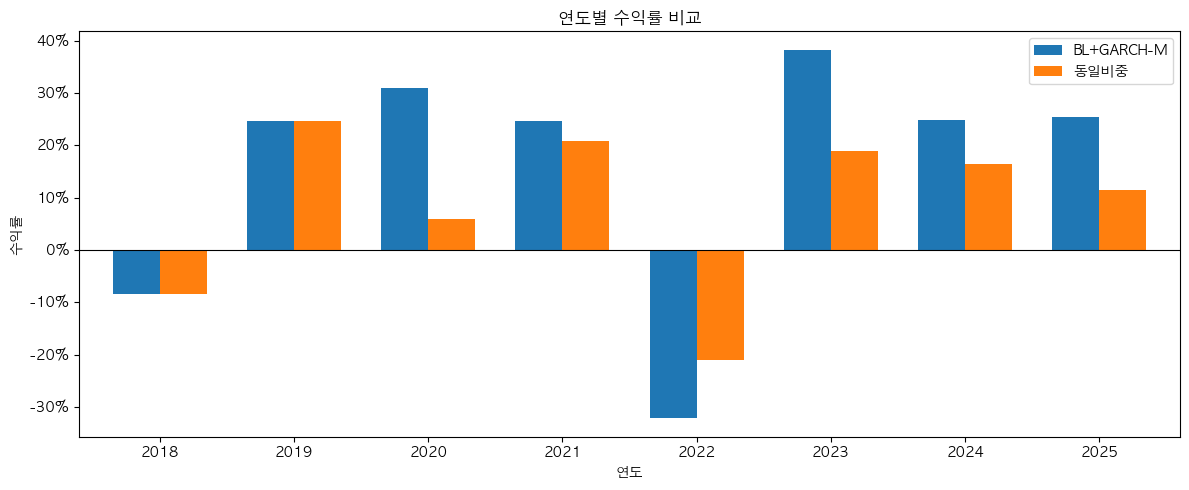

     BL+GARCH-M     동일비중
Date                    
2018     -8.32%   -8.32%
2019     24.63%   24.63%
2020     31.02%    5.88%
2021     24.57%   20.84%
2022    -32.17%  -20.96%
2023     38.29%   19.02%
2024     24.90%   16.49%
2025     25.38%   11.48%


In [257]:
# 연도별 수익률 비교
annual_port  = port_ret.resample('Y').sum()
annual_bench = bench_ret.resample('Y').sum()

annual_compare = pd.DataFrame({
    'BL+GARCH-M': annual_port,
    '동일비중': annual_bench
})

annual_compare.index = annual_compare.index.year

fig, ax = plt.subplots(figsize=(12, 5))
annual_compare.plot(kind='bar', ax=ax, width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('연도별 수익률 비교')
ax.set_ylabel('수익률')
ax.set_xlabel('연도')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(annual_compare.applymap(lambda x: f'{x:.2%}'))